# Perceptron animation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Preparing a toy dataset

In [2]:
##########################
### DATASET
##########################

data = np.genfromtxt('perceptron_toydata.txt', delimiter='\t')
X, y = data[:, :2], data[:, 2]
y = y.astype(np.int)

print('Class label counts:', np.bincount(y))
print('X.shape:', X.shape)
print('y.shape:', y.shape)

# Shuffling & train/test split
shuffle_idx = np.arange(y.shape[0])
shuffle_rng = np.random.RandomState(123)
shuffle_rng.shuffle(shuffle_idx)
X, y = X[shuffle_idx], y[shuffle_idx]

Class label counts: [50 50]
X.shape: (100, 2)
y.shape: (100,)


/var/folders/dd/vx__9cps529_hp5n9w80_36h0000gq/T/ipykernel_16881/2269877568.py:7: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  y = y.astype(np.int)


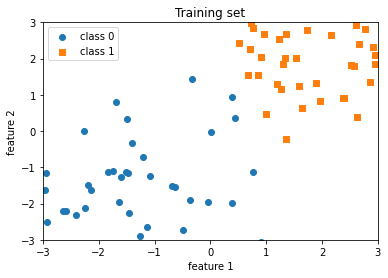

In [3]:
plt.scatter(X[y==0, 0], X[y==0, 1], label='class 0', marker='o')
plt.scatter(X[y==1, 0], X[y==1, 1], label='class 1', marker='s')
plt.title('Training set')
plt.xlabel('feature 1')
plt.ylabel('feature 2')
plt.xlim([-3, 3])
plt.ylim([-3, 3])
plt.legend()
plt.show()

## Defining the Perceptron model

In [4]:
class Perceptron():
    def __init__(self, num_features):
        self.num_features = num_features
        self.weights = np.zeros((num_features, 1), dtype=np.float)
        self.bias = np.zeros(1, dtype=np.float)

    def forward(self, x):
        linear = np.dot(x, self.weights) + self.bias
        predictions = np.where(linear > 0., 1, 0)
        return predictions
        
    def backward(self, x, y):  
        predictions = self.forward(x)
        errors = y - predictions
        return errors
        
    def train(self, x, y, epochs):
        for e in range(epochs):
            
            for i in range(y.shape[0]):
                errors = self.backward(x[i].reshape(1, self.num_features), y[i]).reshape(-1)
                self.weights += (errors * x[i]).reshape(self.num_features, 1)
                self.bias += errors
                
    def evaluate(self, x, y):
        predictions = self.forward(x).reshape(-1)
        accuracy = np.sum(predictions == y) / y.shape[0]
        return accuracy

## Training the Perceptron

In [5]:
all_weights = []
all_biases = []

ppn = Perceptron(num_features=2)

acc = 0

for epoch in range(10):

    for i in range(X.shape[0]):
        
        all_weights.append(ppn.weights.copy())
        all_biases.append(ppn.bias.copy())
        ppn.train(X[i].reshape(1, -1), y[i].reshape(-1), epochs=1)
        
        acc = ppn.evaluate(X, y)
        
        if acc == 1.0:
            break
            
    if acc == 1.0:
        all_weights.append(ppn.weights.copy())
        all_biases.append(ppn.bias.copy())
        break

/var/folders/dd/vx__9cps529_hp5n9w80_36h0000gq/T/ipykernel_16881/3734623960.py:4: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  self.weights = np.zeros((num_features, 1), dtype=np.float)
/var/folders/dd/vx__9cps529_hp5n9w80_36h0000gq/T/ipykernel_16881/3734623960.py:5: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  self.bias = np.zeros(1, d

## Plotting the boundary

/var/folders/dd/vx__9cps529_hp5n9w80_36h0000gq/T/ipykernel_16881/1631871795.py:22: RuntimeWarning: invalid value encountered in true_divide
  y_min = ( (-(w[0] * x_min) - b[0])
/var/folders/dd/vx__9cps529_hp5n9w80_36h0000gq/T/ipykernel_16881/1631871795.py:26: RuntimeWarning: invalid value encountered in true_divide
  y_max = ( (-(w[0] * x_max) - b[0])
/var/folders/dd/vx__9cps529_hp5n9w80_36h0000gq/T/ipykernel_16881/1631871795.py:18: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots()


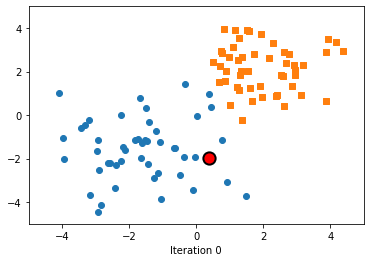

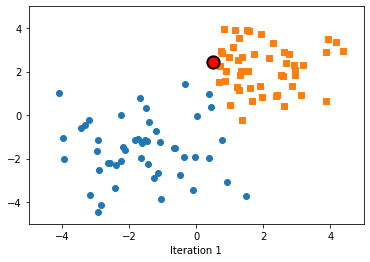

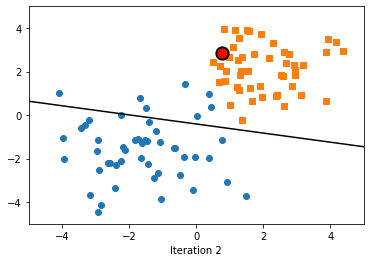

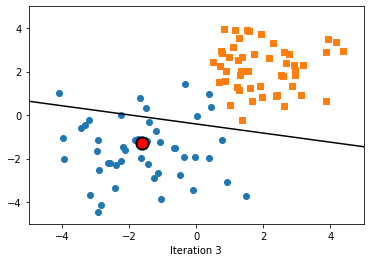

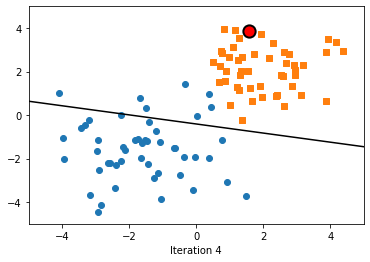

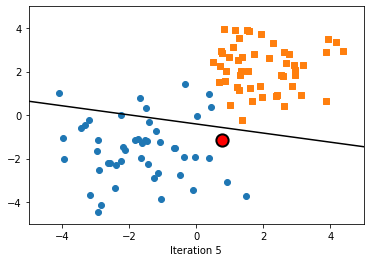

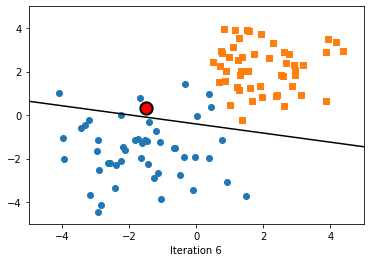

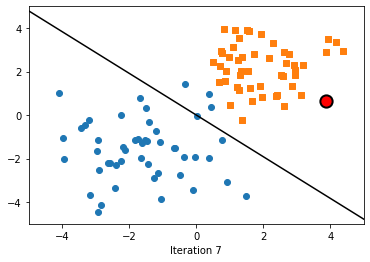

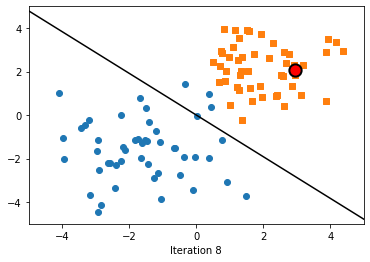

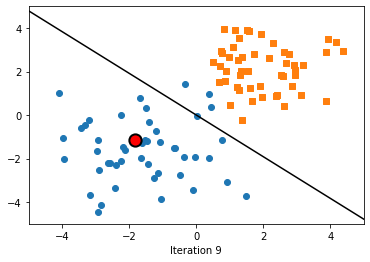

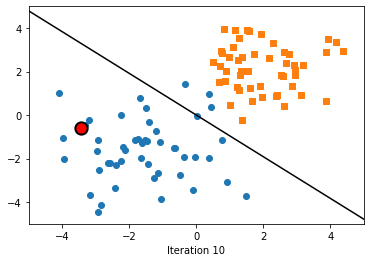

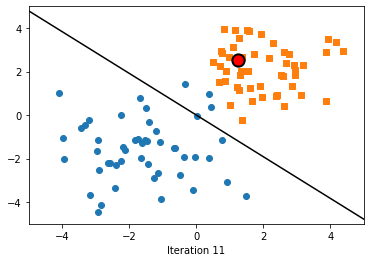

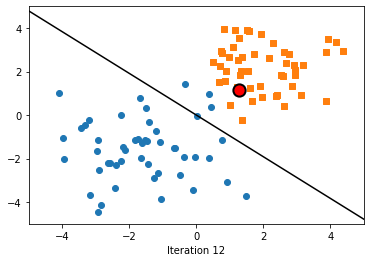

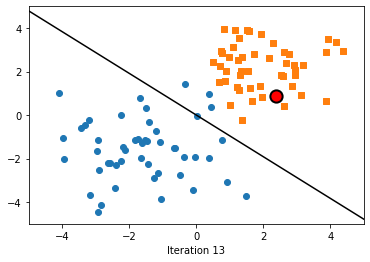

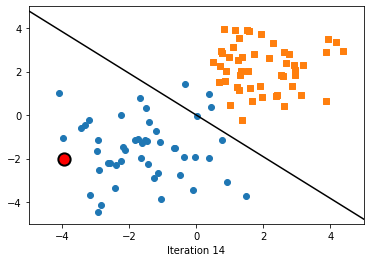

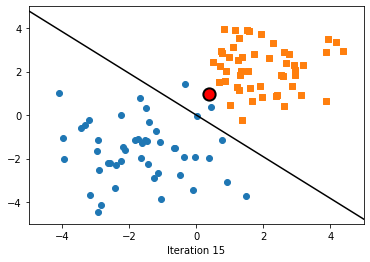

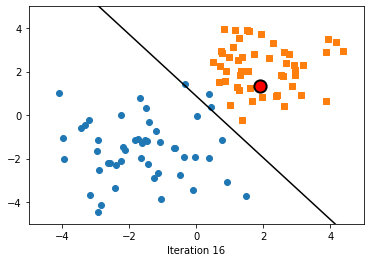

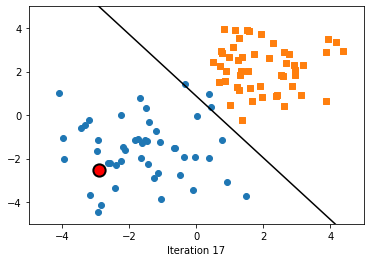

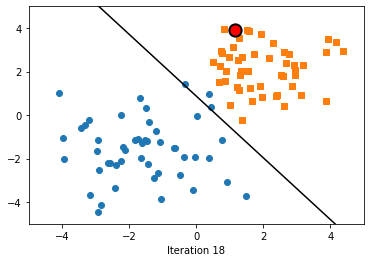

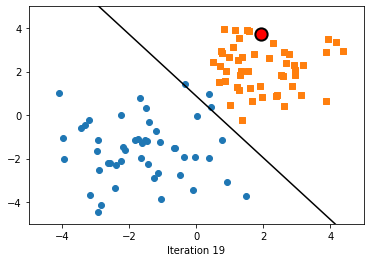

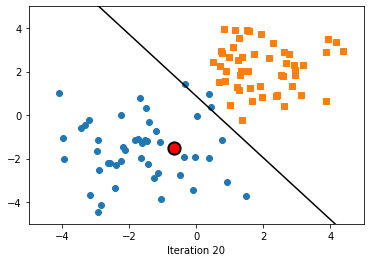

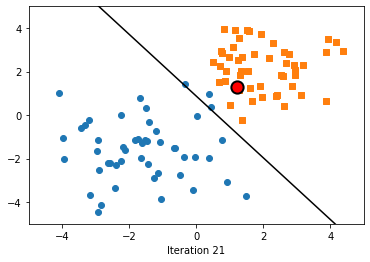

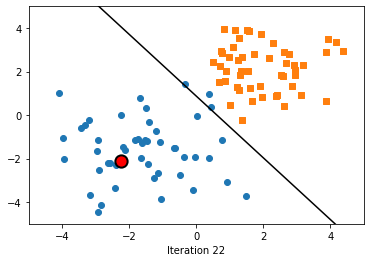

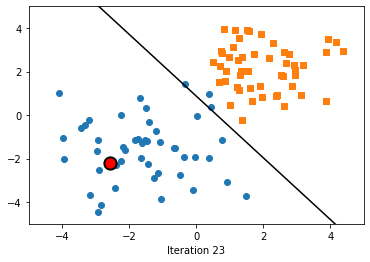

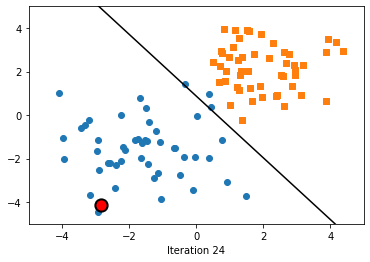

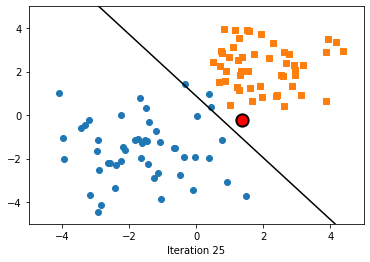

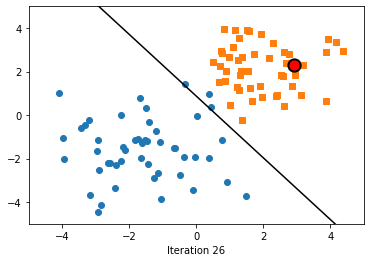

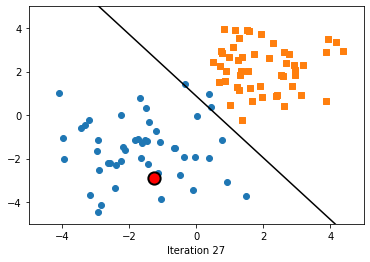

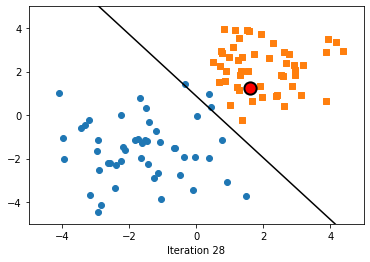

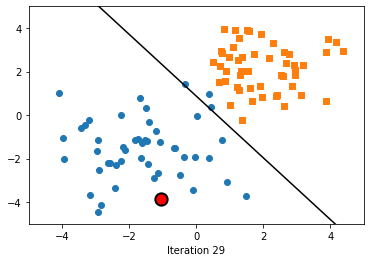

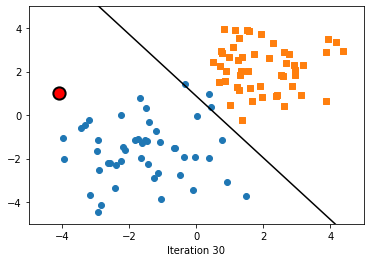

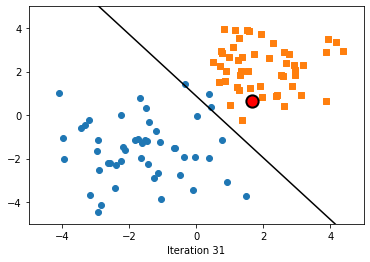

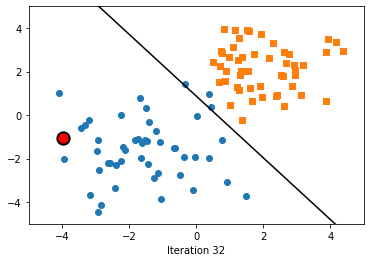

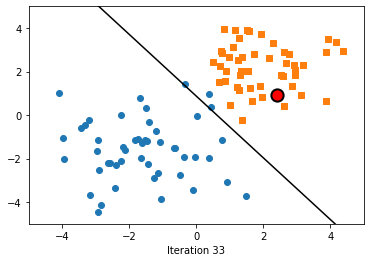

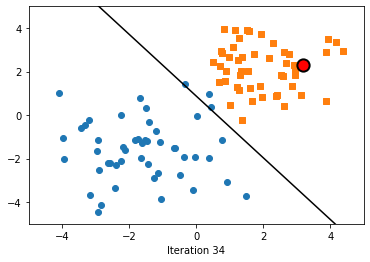

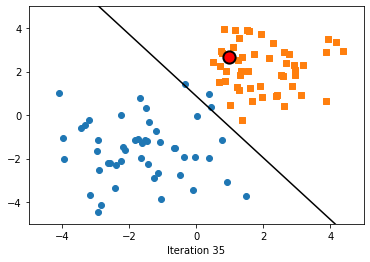

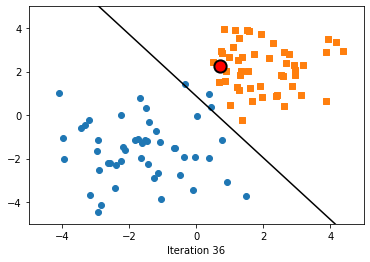

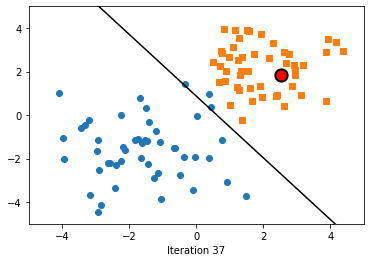

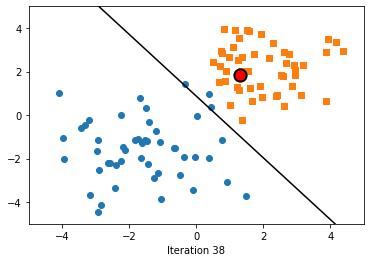

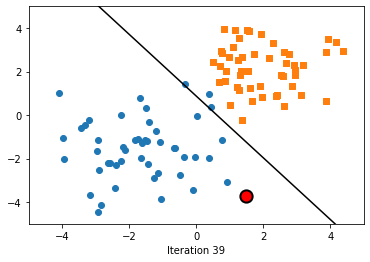

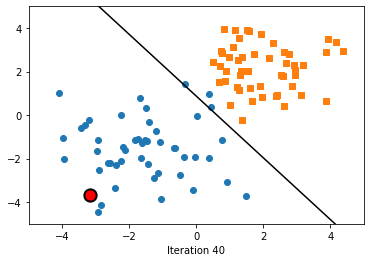

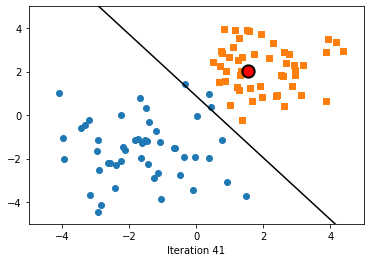

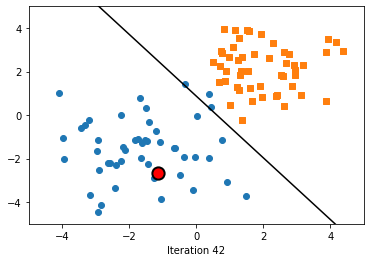

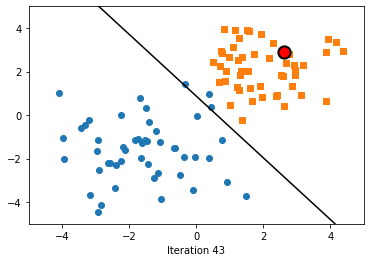

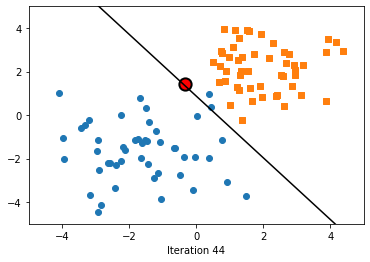

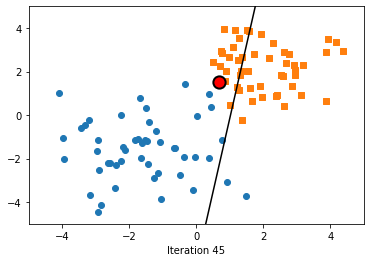

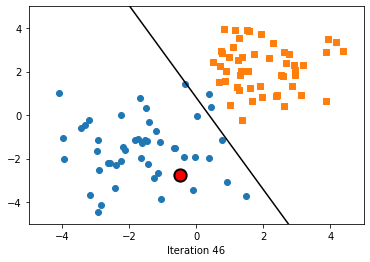

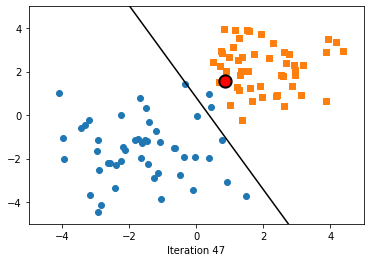

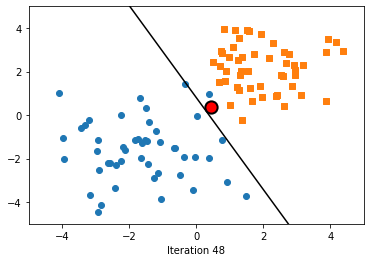

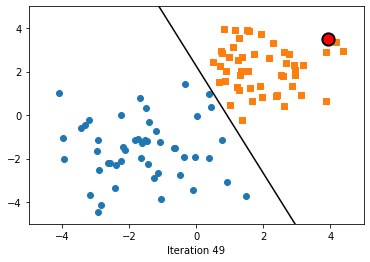

In [6]:
##########################
### 2D Decision Boundary
##########################


import imageio


scatter_highlight_defaults = {'c': 'r',
                              'edgecolor': 'k',
                              'alpha': 1.0,
                              'linewidths': 2,
                              'marker': 'o',
                              's': 150}

def plot(i):
    
    fig, ax = plt.subplots()
    w, b = all_weights[i], all_biases[i]
    
    x_min = -20
    y_min = ( (-(w[0] * x_min) - b[0]) 
              / w[1] )

    x_max = 20
    y_max = ( (-(w[0] * x_max) - b[0]) 
              / w[1] )
    
    ax.set_xlim([-5., 5])
    ax.set_ylim([-5., 5])
    
    ax.set_xlabel('Iteration %d' % i)

    ax.plot([x_min, x_max], [y_min, y_max], color='k')
    
    ax.scatter(X[y==0, 0], X[y==0, 1], label='class 0', marker='o')
    ax.scatter(X[y==1, 0], X[y==1, 1], label='class 1', marker='s')
    
    ax.scatter(X[i][0], X[i][1], **scatter_highlight_defaults)

    fig.canvas.draw();
    image = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8')
    image = image.reshape(fig.canvas.get_width_height()[::-1] + (3,))

    return image


kwargs_write = {'fps':1.0, 'quantizer':'nq'}
imageio.mimsave('training.gif', [plot(i) for i in range(len(all_weights))], fps=1);
